## 1. Imports and Data

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


In [55]:

tickers = {
    "Information Technology": ["AAPL", "MSFT", "NVDA", "AVGO", "CRM"],  # High momentum, growth factor exposure
    "Financials": ["JPM", "BAC", "GS", "MS", "BLK", "WFC"],             # Value factor, rate sensitivity
    "Health Care": ["JNJ", "UNH", "LLY", "ABBV", "MRK", "PFE"],         # Defensive, quality factor
    "Consumer Discretionary": ["AMZN", "TSLA", "HD", "MCD", "NKE", "LOW"], # Cyclical, momentum variation
    "Industrials": ["CAT", "HON", "UNP", "RTX", "GE", "DE"],            # Classic value/quality mix
    "Communication Services": ["GOOGL", "META", "DIS", "NFLX", "T"],    # Growth vs. value spread
    "Consumer Staples": ["PG", "KO", "PEP", "WMT", "COST", "CL"],       # Low vol, defensive
    "Energy": ["XOM", "CVX", "COP", "SLB", "EOG"],                      # Value, commodity beta
    "Utilities": ["NEE", "DUK", "SO", "AEP", "EXC"],                    # Low vol, yield factor
    "Real Estate": ["PLD", "AMT", "EQIX", "SPG", "PSA"],                # Yield, rate sensitivity
    "Materials": ["LIN", "APD", "NEM", "FCX", "SHW"],                   # Cyclical, commodity exposure
}
'''
tickers = {
    "Tech": ["AAPL", "MSFT", "NVDA", "NFLX", "GOOGL", "META", "ORCL", "TSLA"], 
}
'''
all_tickers = [ticker for sector in tickers.values() for ticker in sector]



In [56]:
start_date = "2010-01-01"
end_date = "2025-01-01"

data = yf.download(
    [ticker for sector in tickers.values() for ticker in sector],
    start=start_date,
    end=end_date,
    interval = "1mo"
)["Close"]

# Compute returns
returns = np.log(data).diff().dropna()

# Data Quality Checks
# 1. Are there any NaNs?
print(returns.isna().sum().sum())

# 2. Are they at the start?
print(returns.iloc[0].isna().sum())

# 3. Flag outliers (returns > 50% or < -50%)
outliers = (returns > 0.5) | (returns < -0.5)
outliers_df = returns[outliers].stack(level = 'Ticker')
print(outliers_df)

data.to_csv("data/prices.csv")
returns.to_csv("data/returns.csv")

C:\Users\godwi\AppData\Local\Temp\ipykernel_37952\1760627635.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  60 of 60 completed


0
0
Date        Ticker
2013-05-01  TSLA      0.593717
2016-02-01  FCX       0.506031
2020-03-01  EOG      -0.565959
            SLB      -0.682553
            SPG      -0.792846
2020-08-01  TSLA      0.554719
2022-04-01  NFLX     -0.676915
dtype: float64


In [57]:
# Compare to benchmark
spy_row = yf.download(
    "SPY",
    start=start_date,
    end=end_date,
    interval = "1mo"
)

spy_prices = spy_row["Close"]["SPY"]

spy_returns = np.log(spy_prices).diff().dropna()
spy_returns = spy_returns.reindex(returns.index)
spy_returns.to_csv("data/spy_returns.csv")

# Check shape
print(returns.shape)        # (T, N)
print(spy_returns.shape)    # (T,)
# Confirm all share the same index
assert returns.index.equals(spy_returns.index)

assert len(returns) == len(spy_returns), \
    "returns and spy_returns have different lengths"


C:\Users\godwi\AppData\Local\Temp\ipykernel_37952\2373587483.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy_row = yf.download(


[*********************100%***********************]  1 of 1 completed

(143, 60)
(143,)


## 2. Raw Signals

In [58]:
# Pull Fundamental Data
# Market Cap
shares_dict = {}
for ticker in all_tickers:
    try:
        info = yf.Ticker(ticker).info
        shares = info.get('sharesOutstanding', None)
        shares_dict[ticker] = shares
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")
        shares_dict[ticker] = None

shares_series = pd.Series(shares_dict)
missing = shares_series[shares_series.isna()]
print(missing) # None
market_cap = data.multiply(shares_series, axis=1)
market_cap.to_csv("data/market_cap.csv")
log_market_cap = np.log(market_cap)
log_market_cap.to_csv("data/log_market_cap.csv")

print(log_market_cap.shape) # 120 Months x 60 stocks
print(log_market_cap.head())

Series([], dtype: int64)
(180, 60)
                 AAPL  ABBV        AEP        AMT       AMZN        APD  \
Date                                                                      
2010-01-01  25.159348   NaN  23.028371  23.384753  24.934689  23.064724   
2010-02-01  25.222695   NaN  22.998195  23.389688  24.877169  22.962518   
2010-03-01  25.361125   NaN  23.026977  23.388515  25.014063  23.037906   
2010-04-01  25.466405   NaN  23.030481  23.345354  25.023811  23.082078   
2010-05-01  25.450149   NaN  22.959821  23.338469  24.935087  22.976109   

                 AVGO        BAC        BLK        CAT  ...        SLB  \
Date                                                    ...              
2010-01-01  22.483285  25.137923  23.804409  23.500736  ...  24.882614   
2010-02-01  22.526635  25.230955  23.827433  23.595616  ...  24.844716   
2010-03-01  22.651312  25.299948  23.822668  23.692439  ...  24.885862   
2010-04-01  22.648876  25.299435  23.658849  23.772518  ...  25.00403

In [60]:
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
# Compute Raw Signal Values
# 1. Market Beta
# Run OLS over past 36 months
beta_window = 36
monthly_index = returns.index
beta_panel = pd.DataFrame(np.nan, index = monthly_index, columns = all_tickers)

assert returns.index.equals(spy_returns.index), \
    "returns and spy_returns have different indices — align them first"

for i, date in enumerate(monthly_index):
    if i < beta_window:
        continue  # Not enough data for the first few months


    window_returns = returns.iloc[i-beta_window:i]
    window_spy = spy_returns.iloc[i-beta_window:i]
    
    valid_mask = window_spy.notna() 
    if valid_mask.sum() < 24:
        continue

    spy_window_clean = window_spy[valid_mask] 

    for ticker in all_tickers:
        y = window_returns.loc[window_spy.index, ticker]

        combined_valid = valid_mask & y.notna()

        if combined_valid.sum() < 24: 
            continue

        y_clean = y[combined_valid].values
        spy_clean = window_spy[combined_valid].values
        X_clean = add_constant(spy_clean, has_constant="add")  # Recreate X with cleaned spy data

        try:
            model = OLS(y_clean, X_clean).fit()
            beta_panel.loc[date, ticker] = model.params[1]  # Store the beta coefficient

        except Exception:
            pass

beta_panel.to_csv("data/signal_beta_raw.csv")


    

In [61]:
# Sanity check
print((beta_panel < -1).sum().sum())
print((beta_panel > 3).sum().sum()) 
beta_panel.describe()

0
10


,AAPL,MSFT,NVDA,AVGO,CRM,JPM,BAC,GS,MS,BLK,...,PLD,AMT,EQIX,SPG,PSA,LIN,APD,NEM,FCX,SHW
count,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,...,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000
mean,1.209816,0.997646,1.680791,0.976278,1.234583,1.125008,1.450089,1.319078,1.382783,1.402045,...,0.981958,0.642064,0.563060,1.194146,0.372516,0.889348,0.904857,0.278362,2.168974,1.172564
std,0.126088,0.192603,0.516005,0.233433,0.180872,0.081986,0.174440,0.130643,0.185241,0.197813,...,0.185710,0.360572,0.261462,0.673907,0.296590,0.211928,0.177428,0.275048,0.480583,0.146815
min,0.857286,0.723167,0.889583,0.347591,0.938768,0.908344,1.129596,1.007939,0.968409,1.069550,...,0.720756,0.005016,0.143119,0.270696,-0.111237,0.431366,0.667353,-0.395556,1.354624,0.952005
25%,1.164761,0.837105,1.281470,0.874296,1.089720,1.058653,1.261480,1.222513,1.251680,1.208762,...,0.855900,0.256177,0.342739,0.523968,0.130959,0.743158,0.758976,0.169748,1.749980,1.042355
50%,1.204456,0.983617,1.403219,0.977348,1.214380,1.137254,1.528629,1.313533,1.438043,1.428782,...,0.945992,0.811602,0.554158,1.419555,0.348463,0.955594,0.855404,0.370041,2.118407,1.140324
75%,1.281389,1.117177,2.234364,1.166201,1.348517,1.179548,1.580496,1.417251,1.529233,1.574076,...,1.066044,0.954310,0.652689,1.872238,0.510098,1.081164,1.049469,0.443182,2.477992,1.270550
max,1.493849,1.435643,2.678083,1.353739,1.609270,1.363187,1.736350,1.619204,1.663061,1.676581,...,1.425441,1.133305,1.104262,2.220809,0.965900,1.175877,1.329904,0.856162,3.190343,1.470352


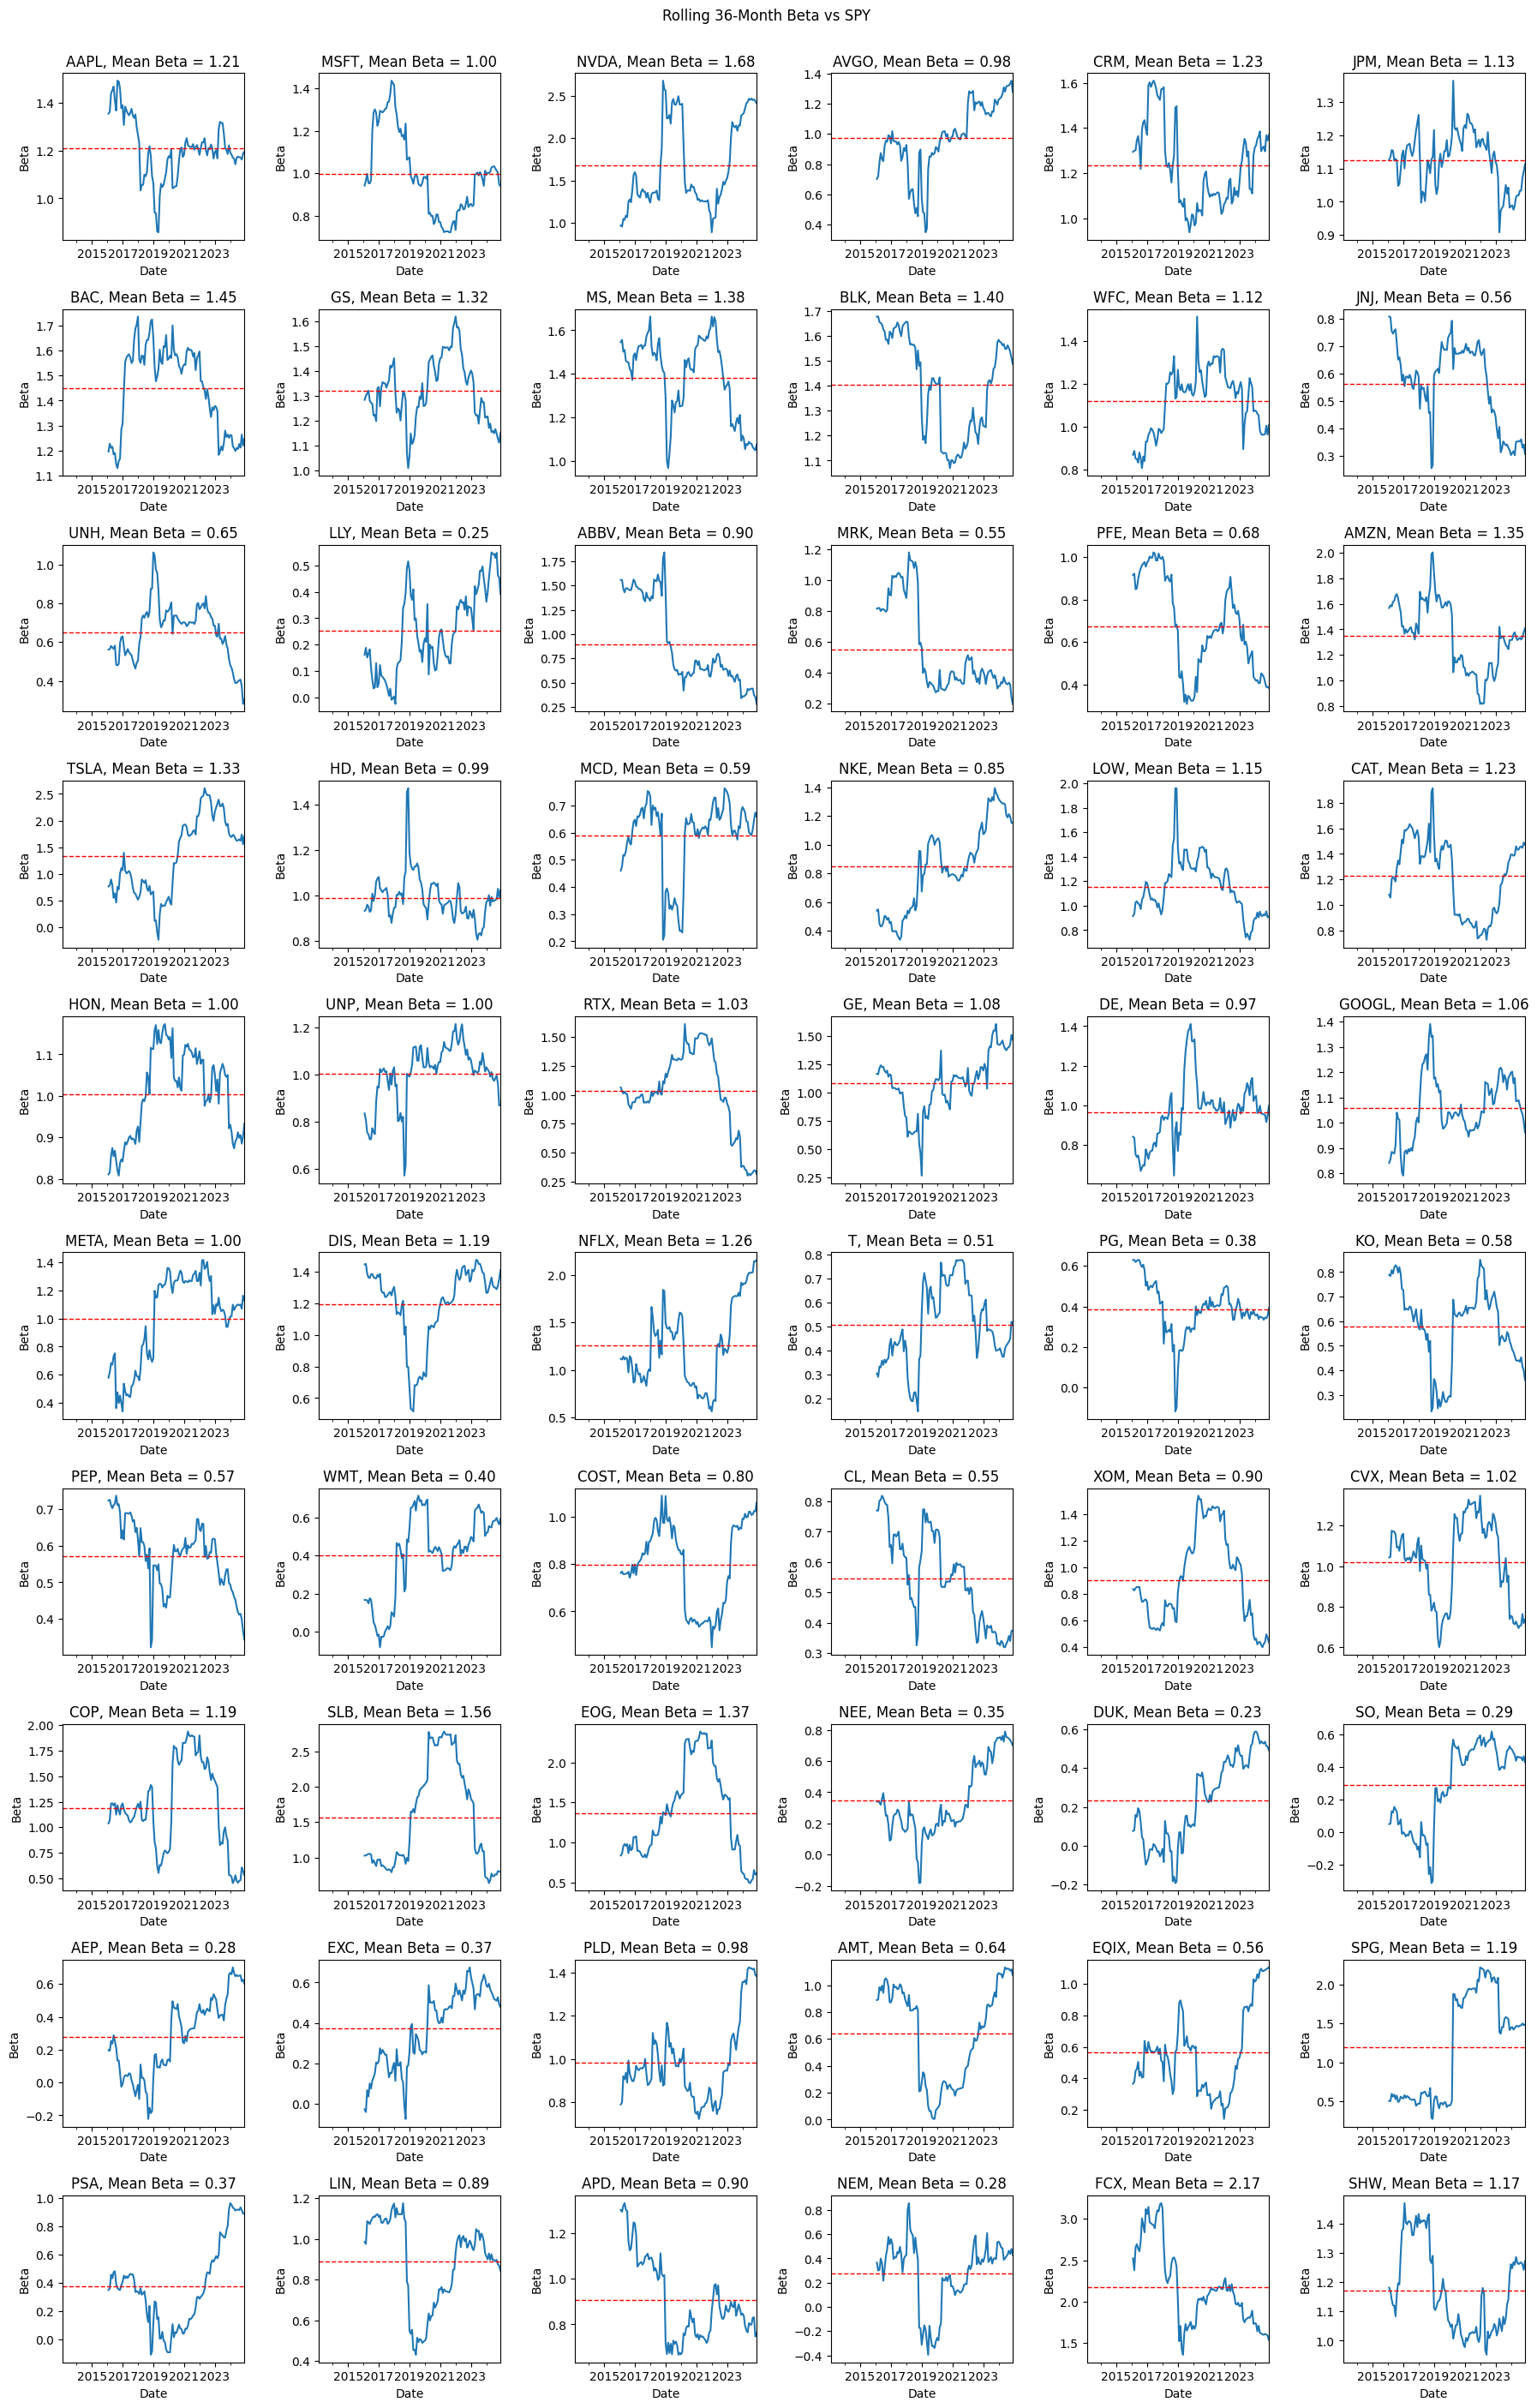

In [62]:
fig, axes = plt.subplots(10, 6, figsize=(18, 28))
axes = axes.flatten()

for i, ticker in enumerate(beta_panel.columns):
    ax = axes[i]
    beta_panel[ticker].plot(ax=ax, linewidth=1.5)
    mean_beta = beta_panel[ticker].mean()
    ax.axhline(mean_beta, color="red", ls="--", linewidth=1, label="Mean")
    ax.set_title(f"{ticker}, Mean Beta = {mean_beta:.2f}")
    ax.set_ylabel("Beta")

for j in range(len(beta_panel.columns), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Rolling 36-Month Beta vs SPY", y=1.002)
fig.tight_layout()
plt.savefig("outputs/beta_panel.png")
plt.show()

In [63]:
# 2. Momentum
mom_start = 12 # 12 months lookback
mom_end = 1 # exclude most recent month - noisy
momentum_panel = pd.DataFrame(np.nan, index = monthly_index, columns = all_tickers)

for i, date in enumerate(monthly_index):
    if i < mom_start:
        continue  # Not enough data for the first few months

    window = returns.iloc[i-mom_start:i-mom_end] 
    compounded = (1 + window).prod(axis = 0, skipna = False) - 1
    momentum_panel.loc[date] = compounded

momentum_panel.to_csv("data/signal_momentum_raw.csv")
print(momentum_panel)

                AAPL      MSFT      NVDA      AVGO       CRM       JPM  \
Date                                                                     
2013-02-01       NaN       NaN       NaN       NaN       NaN       NaN   
2013-03-01       NaN       NaN       NaN       NaN       NaN       NaN   
2013-04-01       NaN       NaN       NaN       NaN       NaN       NaN   
2013-05-01       NaN       NaN       NaN       NaN       NaN       NaN   
2013-06-01       NaN       NaN       NaN       NaN       NaN       NaN   
...              ...       ...       ...       ...       ...       ...   
2024-08-01  0.051980  0.314988  1.367512  0.725579  0.082536  0.285725   
2024-09-01  0.159496  0.258990  1.123252  0.687499  0.107280  0.452157   
2024-10-01  0.315452  0.301165  1.478508  0.911244  0.188168  0.553817   
2024-11-01  0.343209  0.257860  1.694839  0.985215  0.294632  0.518053   
2024-12-01  0.176473  0.064544  1.581452  0.789112  0.123137  0.421125   

                 BAC        GS       

In [64]:
# 3. Size
size_panel = log_market_cap.copy()
size_panel = size_panel.reindex(index=monthly_index)
size_panel = size_panel.reindex(columns=all_tickers)

assert size_panel.index.equals(monthly_index), \
    "Index mismatch between size panel and returns index"

assert size_panel.columns.tolist() == all_tickers, \
    "Column mismatch between size panel and returns columns"

size_panel.to_csv("data/signal_size_raw.csv")

In [65]:
# 4. Low Volatility
vol_window = 12
low_vol_panel = -returns.rolling(window = vol_window, min_periods = 10).std() # Negative for low vol = high score
low_vol_panel = low_vol_panel.reindex(index=monthly_index)
low_vol_panel = low_vol_panel.reindex(columns=all_tickers)
low_vol_panel.to_csv("data/signal_lowvol_raw.csv")

In [66]:
# 5. Long-term Reversal
ltr_start = 36
ltr_end = 12
ltr_panel = pd.DataFrame(np.nan, index = monthly_index, columns = all_tickers)

for i, date in enumerate(monthly_index):
    if i < ltr_start:
        continue  
    
    window = returns.iloc[i-ltr_start:i-ltr_end] 
    compounded = (1 + window).prod(axis = 0, skipna = False) - 1
    ltr_panel.loc[date] = -compounded 

ltr_panel.to_csv("data/signal_ltr_raw.csv")

In [67]:
'''
dates = np.load("data/dates.npy", allow_pickle=True) 
tickers = np.load("data/tickers.npy", allow_pickle=True)  
factors = np.load("data/factors.npy", allow_pickle=True) 


data = pd.read_csv("data/prices.csv", index_col=0, parse_dates=True)
returns = pd.read_csv("data/returns.csv", index_col=0, parse_dates=True).reindex(dates)
spy_returns = pd.read_csv("data/spy_returns.csv", index_col=0, parse_dates=True).reindex(dates)
mktcap_panel = pd.read_csv("data/market_cap.csv", index_col=0, parse_dates=True).reindex(dates)
beta_panel = pd.read_csv("data/signal_beta_raw.csv", index_col=0, parse_dates=True)
momentum_panel = pd.read_csv("data/signal_momentum_raw.csv", index_col=0, parse_dates=True)
size_panel = pd.read_csv("data/signal_size_raw.csv", index_col=0, parse_dates=True)
low_vol_panel = pd.read_csv("data/signal_lowvol_raw.csv", index_col=0, parse_dates=True)
ltr_panel = pd.read_csv("data/signal_ltr_raw.csv", index_col=0, parse_dates=True)
'''



print(beta_panel.shape)
print(momentum_panel.shape)
print(size_panel.shape)
print(low_vol_panel.shape)
print(ltr_panel.shape)

(143, 60)
(143, 60)
(143, 60)
(143, 60)
(143, 60)


In [68]:
# Winsorise, Z-score normalisation and Burn-in
# Set values < 1%ile to 1%ile, > 99%ile to 99%ile, across all stocks, at each time t - hence 'cross sectional'
def winsorise(signal_panel: pd.DataFrame, lower = 0.01, upper = 0.99) -> pd.DataFrame:
    def winsorise_row(row):
        lower_bound = row.quantile(lower)
        upper_bound = row.quantile(upper)
        return row.clip(lower=lower_bound, upper=upper_bound)
    
    return signal_panel.apply(winsorise_row, axis=1)

def normalise(signal_panel: pd.DataFrame) -> pd.DataFrame:
    def normalise_row(row):
        mu = row.mean()
        sig = row.std()
        if sig == 0:
            return row - mu
        return (row - mu) / sig

    return signal_panel.apply(normalise_row, axis=1)

def trim_burn_in(signal_panel: pd.DataFrame, burn_in_periods = 36) -> pd.DataFrame:
    return signal_panel.iloc[burn_in_periods:]



In [72]:
signals_raw = {
    "beta": beta_panel,
    "momentum": momentum_panel,
    "size": size_panel,
    "low_vol": low_vol_panel,
    "ltr": ltr_panel
}

signals_processed = {
    name: trim_burn_in(winsorise(normalise(panel))) for name, panel in signals_raw.items() 
}

np.save("data/signals_raw.npy", signals_raw)
np.save("data/signals_processed.npy", signals_processed)

In [ ]:
# Trim signals due to burn-in
for signal in signals_processed.values():
    print(signal.isna().sum().sum())
    print(signal.shape)

# No NaNs


0
(107, 60)
0
(107, 60)
0
(107, 60)
0
(107, 60)
0
(107, 60)


## 3. Orthogonalise and weights via Information Coefficient

In [100]:
def residualise(y, X):
    X = add_constant(X)
    model = OLS(y, X).fit()
    return model.resid

# 1. Size orthogonal to beta
size_clean = residualise(signals_processed["size"], signals_processed["beta"])

# 2. low vol orthogonal to beta + size
lowvol_clean = residualise(signals_processed["low_vol"], pd.concat([signals_processed["beta"], size_clean], axis=1))

# 3. momentum orthogonal to beta + size + low vol
momentum_clean = residualise(signals_processed["momentum"], pd.concat([signals_processed["beta"], size_clean, lowvol_clean], axis=1))

# 4. ltr orthogonal to beta + size + low vol + momentum
ltr_clean = residualise(signals_processed["ltr"], pd.concat([signals_processed["beta"], size_clean, lowvol_clean, momentum_clean], axis=1))

signals_cleaned = {
    "beta": signals_processed["beta"],
    "momentum": momentum_clean,
    "size": size_clean,
    "low_vol": lowvol_clean,
    "ltr": ltr_clean
}
    
np.save("data/signals_cleaned.npy", signals_cleaned)

dates = signals_cleaned["beta"].index
factors = list(signals_cleaned.keys())




['beta', 'momentum', 'size', 'low_vol', 'ltr']

In [119]:
returns = returns.reindex(dates)

def compute_ic(name: str, signal: pd.DataFrame, returns: pd.DataFrame):
    returns = returns.shift(-1) # align r_{t+1}
    ic_series = pd.DataFrame(index = signal.index, columns = [name])
    
    for t in signal.index:
        x = signal.loc[t]
        r = returns.loc[t]

        valid = x.notna() & r.notna()

        ic = x[valid].corr(r[valid])
        ic_series.loc[t] = ic

    return ic_series



In [120]:
ic_df = pd.DataFrame(index = dates)
for name, signal in signals_cleaned.items():
    ic_df = pd.concat([ic_df, compute_ic(name, signal, returns)], axis = 1)
ic_df.dropna(inplace = True)
ic_df

,beta,momentum,size,low_vol,ltr
Date,,,,,
2016-02-01,0.218135,-0.107445,-0.701622,0.126848,0.212632
2016-03-01,0.315793,-0.092075,0.004995,-0.19935,0.14495
2016-04-01,-0.071507,-0.082668,-0.497413,0.37214,-0.075655
2016-05-01,-0.580409,0.305028,-0.255414,-0.117121,0.192489
2016-06-01,0.351188,-0.148963,-0.550393,0.369847,0.36578
...,...,...,...,...,...
2024-07-01,-0.171736,0.093134,-0.375431,0.321334,0.000286
2024-08-01,0.381367,0.298873,-0.602295,0.183216,0.405976
2024-09-01,0.198333,-0.283896,-0.306885,-0.171837,-0.226952


In [121]:
S_k = ic_df.mean(axis = 0) / ic_df.std(axis = 0) # score for factor k
S_k = S_k / S_k.abs().sum() # normalise
S_k # stability adjusted score


beta        0.094347
momentum   -0.121833
size       -0.607645
low_vol     0.158106
ltr         0.018069
dtype: object